In [ ]:
# Question 1.1
import os
import pandas as pd
import numpy as np

if not os.path.exists('diabetes.csv'):
    np.random.seed(0)
    n = 200
    data = {
        'Pregnancies': np.random.randint(0, 10, size=n),
        'Glucose': np.random.randint(50, 200, size=n),
        'BloodPressure': np.random.randint(30, 120, size=n),
        'SkinThickness': np.random.randint(10, 60, size=n),
        'Insulin': np.random.randint(15, 276, size=n),
        'BMI': np.round(np.random.uniform(18, 45, size=n),1),
        'DiabetesPedigreeFunction': np.round(np.random.uniform(0.1, 2.5, size=n),3),
        'Age': np.random.randint(21, 80, size=n),
        'Outcome': np.random.randint(0,2,size=n)
    }
    df_small = pd.DataFrame(data)
    for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
        mask = np.random.rand(n) < 0.05
        df_small.loc[mask, col] = 0
    df_small.to_csv('diabetes.csv', index=False)

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5,103,30,53,261,26.2,2.197,32,0
1,0,101,69,51,95,20.0,2.102,77,0
2,3,198,54,56,170,29.5,0.613,74,0
3,3,79,88,10,62,20.9,1.951,35,1
4,7,117,0,0,129,33.3,0.129,53,1


In [ ]:
# Question 1.1
print('shape:', df.shape)
print('\ninfo:')
print(df.info())
print('\nmissing counts:')
print(df.isnull().sum())
print('\ndescribe:\n', df.describe())

shape: (200, 9)

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               200 non-null    int64  
 1   Glucose                   200 non-null    int64  
 2   BloodPressure             200 non-null    int64  
 3   SkinThickness             200 non-null    int64  
 4   Insulin                   200 non-null    int64  
 5   BMI                       200 non-null    float64
 6   DiabetesPedigreeFunction  200 non-null    float64
 7   Age                       200 non-null    int64  
 8   Outcome                   200 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 14.2 KB
None

missing counts:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigre

In [ ]:
# Question 1.2
cols_with_zeros = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
print('missing after replacing zeros:')
print(df.isnull().sum())
for c in cols_with_zeros:
    if df[c].isnull().any():
        df[c].fillna(df[c].median(), inplace=True)
print('\nmissing after imputation:')
print(df.isnull().sum())

df.head()

missing after replacing zeros:
Pregnancies                  0
Glucose                     10
BloodPressure               20
SkinThickness                6
Insulin                      7
BMI                          5
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

missing after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


/tmp/ipython-input-3842518200.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].median(), inplace=True)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5,103.0,30.0,53.0,261.0,26.2,2.197,32,0
1,0,101.0,69.0,51.0,95.0,20.0,2.102,77,0
2,3,198.0,54.0,56.0,170.0,29.5,0.613,74,0
3,3,79.0,88.0,10.0,62.0,20.9,1.951,35,1
4,7,117.0,76.0,34.0,129.0,33.3,0.129,53,1


In [ ]:
# Question 1.3
X = df.drop(columns=['Outcome']).values
y = df['Outcome'].values

def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
    np.random.seed(random_seed)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    test_split_size = int(len(X) * test_size)
    test_indices = indices[:test_split_size]
    train_indices = indices[test_split_size:]
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.3)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (140, 8)
X_test shape: (60, 8)
y_train shape: (140,)
y_test shape: (60,)


In [ ]:
# Question 1.4
import math

def euclidean_distance(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if a.shape != b.shape:
        raise ValueError('Points must have same dimension')
    return math.sqrt(np.sum((a - b) ** 2))

def knn_predict_single(query, X_train, y_train, k=3):
    distances = np.linalg.norm(X_train - query, axis=1)
    idx = np.argsort(distances)[:k]
    neighbors = y_train[idx]
    counts = np.bincount(neighbors)
    return np.argmax(counts)

def knn_predict(X_test, X_train, y_train, k=3):
    preds = [knn_predict_single(x, X_train, y_train, k) for x in X_test]
    return np.array(preds)

def compute_accuracy(y_true, y_pred):
    return (np.sum(y_true == y_pred) / len(y_true)) * 100

preds = knn_predict(X_test, X_train, y_train, k=3)
acc_original_k3 = compute_accuracy(y_test, preds)
print(f'Accuracy on original data (k=3): {acc_original_k3:.2f}%')

Accuracy on original data (k=3): 60.00%


In [ ]:
# Question 2.1
X_df = pd.DataFrame(X, columns=df.drop(columns=['Outcome']).columns)
X_scaled = (X_df - X_df.min()) / (X_df.max() - X_df.min())
X_scaled = X_scaled.values

Xs_train, Xs_test, ys_train, ys_test = train_test_split_scratch(X_scaled, y, test_size=0.3)

preds_scaled = knn_predict(Xs_test, Xs_train, ys_train, k=3)
acc_scaled_k3 = compute_accuracy(ys_test, preds_scaled)
print(f'Accuracy on scaled data (k=3): {acc_scaled_k3:.2f}%')

Accuracy on scaled data (k=3): 48.33%


In [ ]:
# Question 2.2
print('Original k=3 accuracy:', f'{acc_original_k3:.2f}%')
print('Scaled k=3 accuracy:  ', f'{acc_scaled_k3:.2f}%')

Original k=3 accuracy: 60.00%
Scaled k=3 accuracy:   48.33%


In [ ]:
# Question 3.1
import time
ks = list(range(1,16))
accs_orig = []
accs_scaled = []
times_orig = []
times_scaled = []

for k in ks:
    t0 = time.time()
    p = knn_predict(X_test, X_train, y_train, k=k)
    t1 = time.time()
    acc = compute_accuracy(y_test, p)
    accs_orig.append(acc)
    times_orig.append(t1-t0)

    t0 = time.time()
    ps = knn_predict(Xs_test, Xs_train, ys_train, k=k)
    t1 = time.time()
    accs_scaled.append(compute_accuracy(ys_test, ps))
    times_scaled.append(t1-t0)

print('ks:', ks)
print('accs_orig:', [round(a,2) for a in accs_orig])
print('accs_scaled:', [round(a,2) for a in accs_scaled])
print('times_orig (s):', [round(t,4) for t in times_orig])
print('times_scaled (s):', [round(t,4) for t in times_scaled])

ks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
accs_orig: [np.float64(66.67), np.float64(63.33), np.float64(60.0), np.float64(55.0), np.float64(60.0), np.float64(58.33), np.float64(60.0), np.float64(60.0), np.float64(61.67), np.float64(61.67), np.float64(61.67), np.float64(60.0), np.float64(60.0), np.float64(60.0), np.float64(58.33)]
accs_scaled: [np.float64(41.67), np.float64(45.0), np.float64(48.33), np.float64(46.67), np.float64(46.67), np.float64(43.33), np.float64(40.0), np.float64(41.67), np.float64(41.67), np.float64(41.67), np.float64(45.0), np.float64(45.0), np.float64(43.33), np.float64(36.67), np.float64(43.33)]
times_orig (s): [0.0014, 0.0013, 0.0011, 0.0011, 0.0012, 0.0012, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0012, 0.0011, 0.0026]
times_scaled (s): [0.0011, 0.0012, 0.0011, 0.0011, 0.0012, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0016, 0.0011]


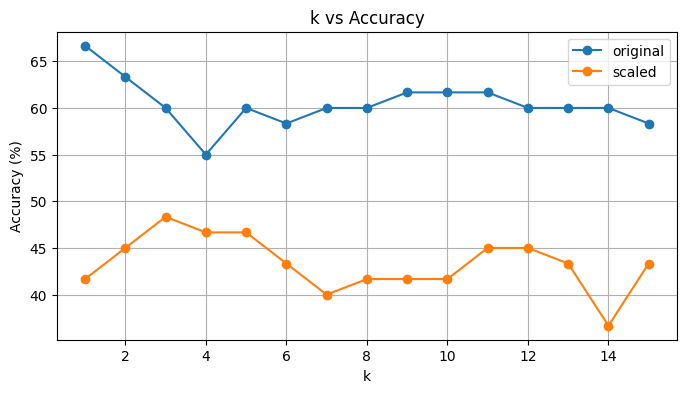

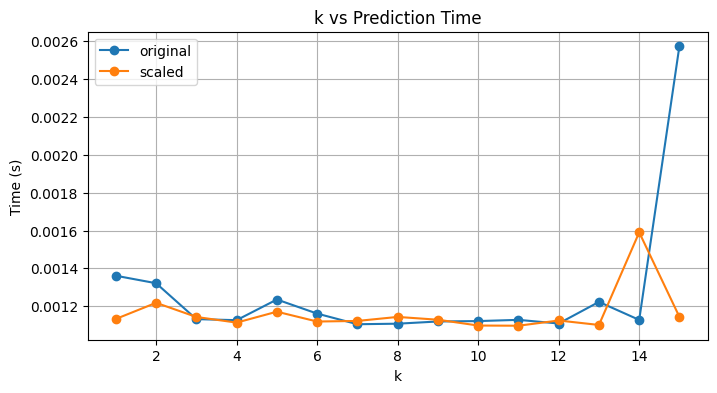

In [ ]:
# Question 3.2
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(ks, accs_orig, marker='o', label='original')
plt.plot(ks, accs_scaled, marker='o', label='scaled')
plt.xlabel('k')
plt.ylabel('Accuracy (%)')
plt.title('k vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(ks, times_orig, marker='o', label='original')
plt.plot(ks, times_scaled, marker='o', label='scaled')
plt.xlabel('k')
plt.ylabel('Time (s)')
plt.title('k vs Prediction Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Question 3.3
best_k_orig = ks[np.argmax(accs_orig)]
best_acc_orig = max(accs_orig)
best_k_scaled = ks[np.argmax(accs_scaled)]
best_acc_scaled = max(accs_scaled)

print(f'Best k (original): {best_k_orig} with accuracy {best_acc_orig:.2f}%')
print(f'Best k (scaled)  : {best_k_scaled} with accuracy {best_acc_scaled:.2f}%')

print('\nNote: times shown are only prediction times, training in k-NN is just storing training set.')

Best k (original): 1 with accuracy 66.67%
Best k (scaled)  : 3 with accuracy 48.33%

Note: times shown are only prediction times, training in k-NN is just storing training set.


In [ ]:
# Question 4
print('Challenges:')
print('- High prediction time because distance computed to all points.')
print('- Large memory to store dataset.')
print('- Curse of dimensionality degrades distance quality in high-dim spaces.')

print('\nStrategies to improve:')
print('- Use approximate nearest neighbors (e.g., KD-Trees, locality sensitive hashing).')
print('- Dimensionality reduction (PCA) or feature selection.')
print('- Use efficient vectorized operations or batch processing.')

Challenges:
- High prediction time because distance computed to all points.
- Large memory to store dataset.
- Curse of dimensionality degrades distance quality in high-dim spaces.

Strategies to improve:
- Use approximate nearest neighbors (e.g., KD-Trees, locality sensitive hashing).
- Dimensionality reduction (PCA) or feature selection.
- Use efficient vectorized operations or batch processing.
